In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load directly from URL
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
df = pd.read_csv(url)

print("✅ Iris Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Species: {df['species'].unique()}")
df.head(10)

✅ Iris Dataset loaded!
Shape: (150, 5)
Species: ['setosa' 'versicolor' 'virginica']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [2]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

species_colors = {
    'setosa':     '#2E86AB',
    'versicolor': '#A23B72',
    'virginica':  '#F18F01'
}

In [3]:
print("=== DATASET INFO ===")
df.info()

print("\n=== STATISTICS ===")
df.describe().round(2)

print("\n=== MEAN PER SPECIES ===")
print(df.groupby('species').mean().round(2))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== COUNT PER SPECIES ===")
print(df['species'].value_counts())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== STATISTICS ===

=== MEAN PER SPECIES ===
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.42          1.46         0.24
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03

=== MISSING VALUES ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== COUNT PER SPECIES =

<Figure size 1000x600 with 0 Axes>

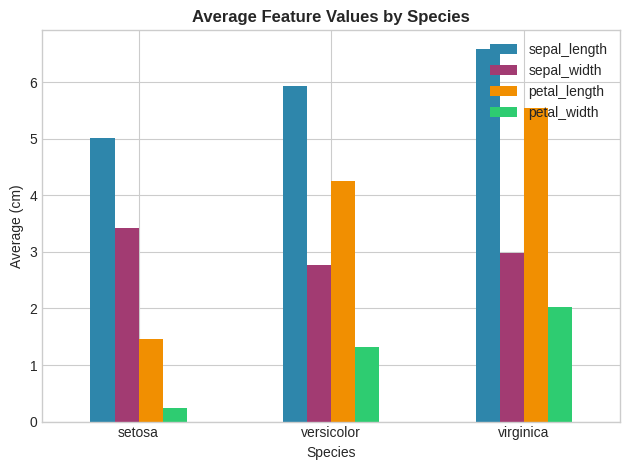

📊 bar_chart.png saved!


In [5]:
plt.figure(figsize=(10, 6))
df.groupby('species').mean().plot(kind='bar', color=['#2E86AB','#A23B72','#F18F01','#2ECC71'])
plt.title('Average Feature Values by Species', fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Average (cm)')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 bar_chart.png saved!")

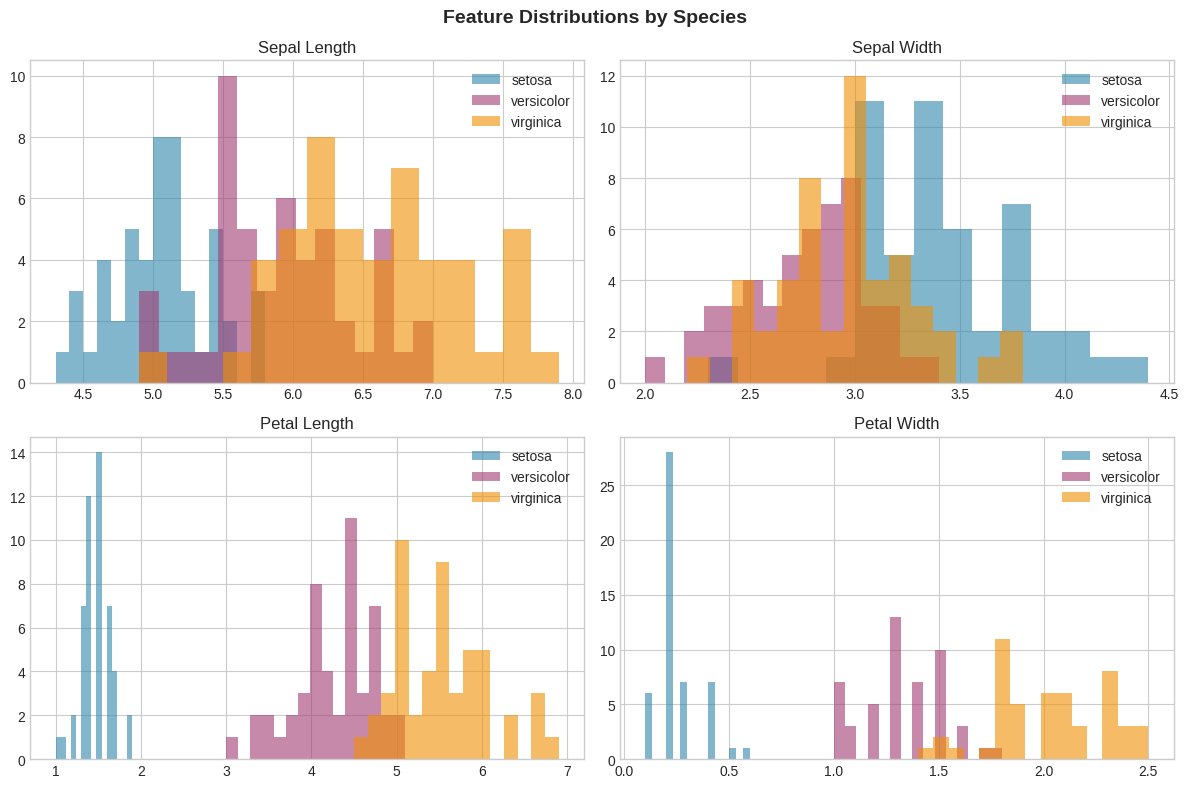

📊 histogram.png saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Species', fontweight='bold', fontsize=14)

for ax, feature in zip(axes.flatten(), features):
    for species, color in species_colors.items():
        df[df['species'] == species][feature].hist(
            ax=ax, bins=15, alpha=0.6, label=species, color=color)
    ax.set_title(feature.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.savefig('histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 histogram.png saved!")

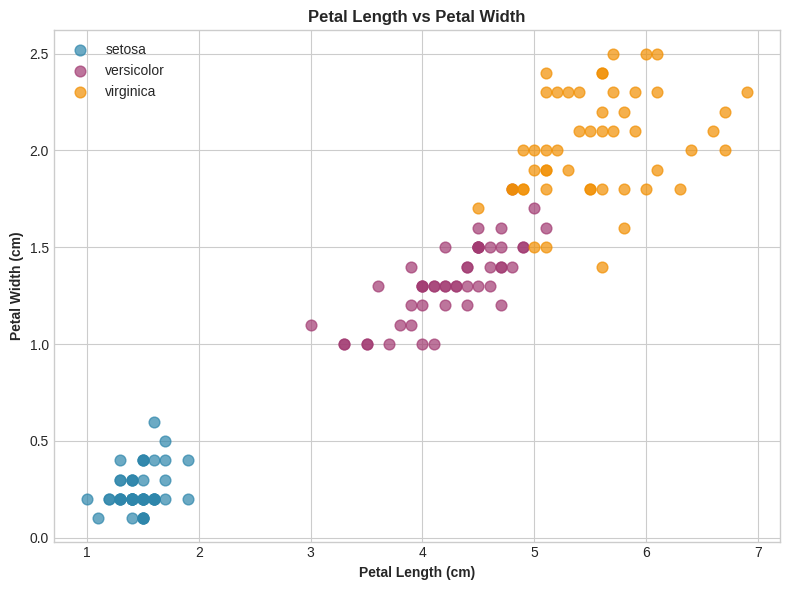

📊 scatter_plot.png saved!


In [7]:
plt.figure(figsize=(8, 6))

for species, color in species_colors.items():
    subset = df[df['species'] == species]
    plt.scatter(subset['petal_length'], subset['petal_width'],
                label=species, color=color, alpha=0.7, s=60)

plt.xlabel('Petal Length (cm)', fontweight='bold')
plt.ylabel('Petal Width (cm)', fontweight='bold')
plt.title('Petal Length vs Petal Width', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 scatter_plot.png saved!")

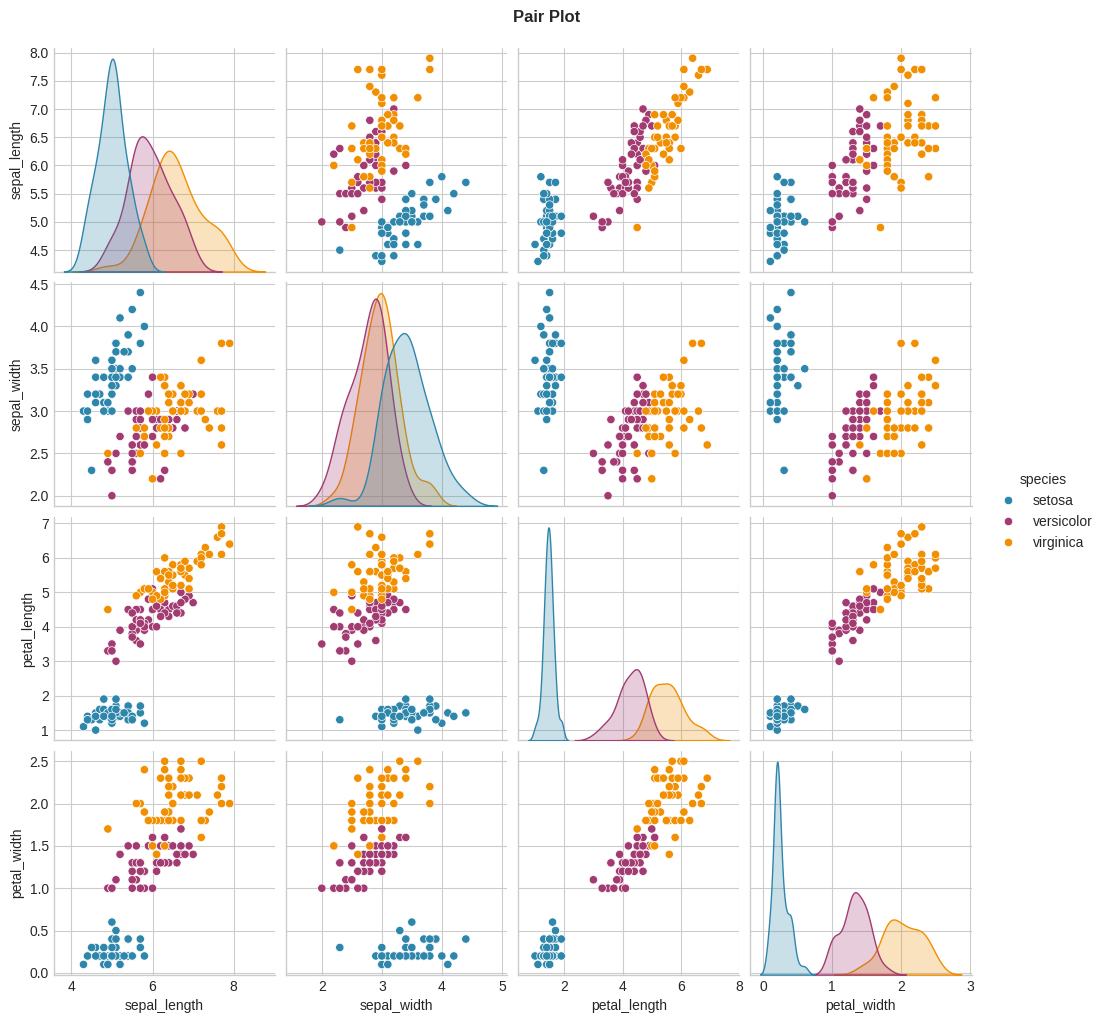

📊 pairplot.png saved!


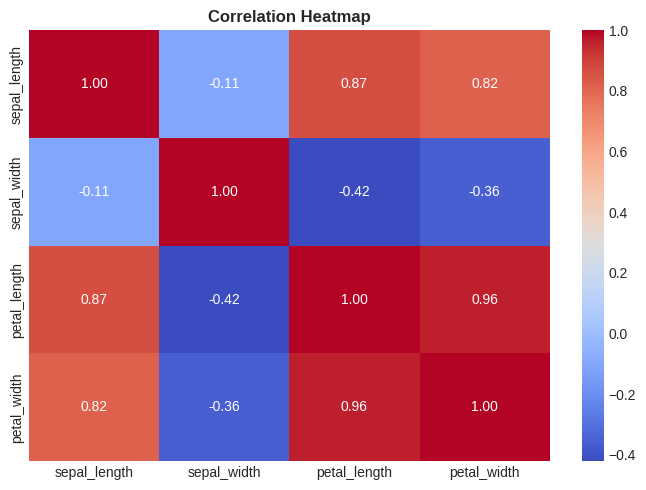

📊 heatmap.png saved!


In [8]:
# Pair plot
sns.pairplot(df, hue='species', palette=species_colors)
plt.suptitle('Pair Plot', y=1.02, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 pairplot.png saved!")

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns='species').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 heatmap.png saved!")

In [9]:
from google.colab import files

files.download('bar_chart.png')
files.download('histogram.png')
files.download('scatter_plot.png')
files.download('pairplot.png')
files.download('heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>